Importing libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

pd.set_option("display.max_columns",100)

In [2]:
# loading the dataset

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# mounting the drive
fpath="/content/drive/MyDrive/Colab Notebooks/Datasets/Graduate Placement Dataset - Sheet1 (3).csv"

df=pd.read_csv(fpath)
df.head()

,Graduate ID,Gender,Nationality,Refugee Status,Disability status,Youth (18-35),Program Name,Sponsorship Type,Graduation Date,Cohort,Education Level,Placement Status
0,G0001,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,26th June 2025,Feb 2025,Bachelor's Degree,Employed
1,G0002,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,26th June 2025,Feb 2025,Bachelor's Degree,Employed
2,G0003,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,26th June 2025,Feb 2025,Bachelor's Degree,Employed
3,G0004,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,26th June 2025,Feb 2025,Certificate,Employed
4,G0005,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,26th June 2025,Feb 2025,Bachelor's Degree,Employed


In [4]:
df.shape

(2387, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2387 entries, 0 to 2386
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Graduate ID        2387 non-null   object
 1   Gender             2387 non-null   object
 2   Nationality        2387 non-null   object
 3   Refugee Status     2387 non-null   object
 4   Disability status  2386 non-null   object
 5   Youth (18-35)      2387 non-null   object
 6   Program Name       2387 non-null   object
 7   Sponsorship Type   2387 non-null   object
 8   Graduation Date    2382 non-null   object
 9   Cohort             2382 non-null   object
 10  Education Level    1499 non-null   object
 11  Placement Status   2387 non-null   object
dtypes: object(12)
memory usage: 223.9+ KB


In [6]:
df.describe(include="all")

,Graduate ID,Gender,Nationality,Refugee Status,Disability status,Youth (18-35),Program Name,Sponsorship Type,Graduation Date,Cohort,Education Level,Placement Status
count,2387,2387,2387,2387,2386,2387,2387,2387,2382,2382,1499,2387
unique,2387,3,18,4,6,6,12,6,5,15,10,2
top,G2387,Female,Ugandan,No,No,Yes,Foundations of Software Development,10X Scholarship,June 2026,Mop Up May 2026,Bachelor's Degree,Open to work
freq,1,2137,2129,2124,1838,2087,1561,2018,1612,802,505,1289


In [7]:
df.columns

Index(['Graduate ID', 'Gender', 'Nationality', 'Refugee Status',
       'Disability status', 'Youth (18-35)', 'Program Name',
       'Sponsorship Type', 'Graduation Date', 'Cohort', 'Education Level',
       'Placement Status'],
      dtype='object')

## Dataset Description

| Column | Description |
|---------|-------------|
| Graduate ID | Unique identifier for each graduate |
| Gender | Graduate's gender |
| Nationality | Country of origin |
| Refugee Status | Indicates whether the graduate is a refugee |
| Disability Status | Indicates whether the graduate has a disability |
| Youth (18–35) | Whether the graduate falls within the youth age category |
| Program Name | Training program completed |
| Sponsorship Type | Source of funding for the training |
| Graduation Date | Date the graduate completed the program |
| Cohort | Training cohort |
| Education Level | Highest level of education attained |
| Placement Status | Employment status within six months (Target Variable) |

In [8]:
# checking to Understand the Dataset
df.isnull().sum()

,0
Graduate ID,0
Gender,0
Nationality,0
Refugee Status,0
Disability status,1
Youth (18-35),0
Program Name,0
Sponsorship Type,0
Graduation Date,5
Cohort,5


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

,0
Graduate ID,2387
Gender,3
Nationality,18
Refugee Status,4
Disability status,6
Youth (18-35),6
Program Name,12
Sponsorship Type,6
Graduation Date,5
Cohort,15


In [11]:
# defining the target Variable
y=df["Placement Status"]

**Data Cleaning and Preparation**

In [12]:
#checking for missing values
df.isnull().sum()

,0
Graduate ID,0
Gender,0
Nationality,0
Refugee Status,0
Disability status,1
Youth (18-35),0
Program Name,0
Sponsorship Type,0
Graduation Date,5
Cohort,5


In [13]:
# Check missing values and percentages

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
Education Level,888,37.201508
Graduation Date,5,0.209468
Cohort,5,0.209468
Disability status,1,0.041894
Refugee Status,0,0.000000
Nationality,0,0.000000
Gender,0,0.000000
Graduate ID,0,0.000000
Sponsorship Type,0,0.000000
Program Name,0,0.000000


The table above shows the number and percentage of missing values in each column. Columns with missing values will be cleaned before training the machine learning models to ensure data quality and improve prediction performance.

In [14]:
# Remove duplicate rows

df = df.drop_duplicates()

# Verify duplicates have been removed

df.duplicated().sum()

np.int64(0)

Duplicate records were checked and removed to ensure each graduate is represented only once in the dataset.

In [15]:
#checking datatypes
df.dtypes

,0
Graduate ID,object
Gender,object
Nationality,object
Refugee Status,object
Disability status,object
Youth (18-35),object
Program Name,object
Sponsorship Type,object
Graduation Date,object
Cohort,object


In [16]:
# converting graduation date
df["Graduation Date"].head(20)

,Graduation Date
0,26th June 2025
1,26th June 2025
2,26th June 2025
3,26th June 2025
4,26th June 2025
5,26th June 2025
6,26th June 2025
7,26th June 2025
8,26th June 2025
9,26th June 2025


In [17]:
df["Graduation Date"] = pd.to_datetime(
    df["Graduation Date"],
    format="mixed",
    dayfirst=True
)

In [18]:
# removing unnecesary columns
df.drop(columns=["Graduate ID"], inplace=True)

In [19]:
df.isnull().sum()

,0
Gender,0
Nationality,0
Refugee Status,0
Disability status,1
Youth (18-35),0
Program Name,0
Sponsorship Type,0
Graduation Date,5
Cohort,5
Education Level,888


In [20]:

# Display missing values and their percentages

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage.round(2)
})

missing_table.sort_values(by="Percentage (%)", ascending=False)

,Missing Values,Percentage (%)
Education Level,888,37.20
Graduation Date,5,0.21
Cohort,5,0.21
Disability status,1,0.04
Refugee Status,0,0.00
Gender,0,0.00
Nationality,0,0.00
Sponsorship Type,0,0.00
Program Name,0,0.00
Youth (18-35),0,0.00


The table above provides both the number and percentage of missing values for each variable.

Education Level has the highest percentage of missing values and therefore requires special handling.

In [21]:
# Handle missing values

# Disability Status with the most common value

df["Disability status"] = df["Disability status"].fillna(
    df["Disability status"].mode()[0]
)

In [22]:
# Fill missing Education Level with 'Unknown'

df["Education Level"] = df["Education Level"].fillna("Unknown")

In [23]:
# Fill missing Cohort with 'Unknown'

df["Cohort"] = df["Cohort"].fillna("Unknown")

In [24]:
# Display rows where Graduation Date is missing

df[df["Graduation Date"].isnull()]

,Gender,Nationality,Refugee Status,Disability status,Youth (18-35),Program Name,Sponsorship Type,Graduation Date,Cohort,Education Level,Placement Status
1589,Female,Ugandan,No,No,Yes,CSE JAVASCRIPT,10X Scholarship,NaT,Unknown,Unknown,Employed
1590,Female,Ugandan,No,No,Yes,CSE JAVASCRIPT,10X Scholarship,NaT,Unknown,Unknown,Employed
1591,Female,Rwandan,Yes,No,Yes,CSE JAVASCRIPT,10X Scholarship,NaT,Unknown,Unknown,Employed
1592,Female,Ugandan,No,No,Yes,CSE PYTHON,10X Scholarship,NaT,Unknown,Unknown,Employed
1593,Female,Ugandan,No,No,Yes,CSE JAVASCRIPT,10X Scholarship,NaT,Unknown,Unknown,Employed


In [25]:
# Remove rows with missing Graduation Date

df = df.dropna(subset=["Graduation Date"])

In [26]:
# Verify that missing values have been handled

df.isnull().sum()

,0
Gender,0
Nationality,0
Refugee Status,0
Disability status,0
Youth (18-35),0
Program Name,0
Sponsorship Type,0
Graduation Date,0
Cohort,0
Education Level,0


The dataset has been cleaned by handling missing values, removing duplicate records, converting the Graduation Date column into a datetime format, creating new features (Graduation Year and Graduation Month), and removing the Graduate ID column. The cleaned dataset is now ready for Exploratory Data Analysis (EDA) and Machine Learning.

In [27]:
import re

# Function to remove date suffixes

def remove_suffix(date):
    if pd.isnull(date):
        return date
    return re.sub(r'(\d+)(st|nd|rd|th)', r'\1', str(date))

df["Graduation Date"] = df["Graduation Date"].apply(remove_suffix)

In [28]:
df["Graduation Date"] = pd.to_datetime(
    df["Graduation Date"],
    dayfirst=True
)

/tmp/ipykernel_2460/3183124873.py:1: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Graduation Date"] = pd.to_datetime(


In [29]:
df["Graduation Date"].head()

,Graduation Date
0,2025-06-26
1,2025-06-26
2,2025-06-26
3,2025-06-26
4,2025-06-26


In [30]:
# Create Graduation Year

df["Graduation Year"] = df["Graduation Date"].dt.year

In [31]:
# Create Graduation Month

df["Graduation Month"] = df["Graduation Date"].dt.month

In [108]:
# ============================================================
# Consolidated categorical cleanup — fixes ALL messy text columns
# in one place, before the cleaned dataset is saved and before
# any EDA chart is built on it.
# ============================================================

# Step 1: standardize whitespace (including non-breaking spaces) and casing
categorical_cols = [
    "Gender", "Refugee Status", "Disability status",
    "Program Name", "Sponsorship Type", "Nationality", "Youth (18-35)"
]

for col in categorical_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("\xa0", " ", regex=False)  # non-breaking space -> regular space
        .str.strip()
    )

# Step 2: fix known typo/casing variants for each column

# Gender is Male/Female — not a Yes/No field — title-case is sufficient
df["Gender"] = df["Gender"].str.title()

# Yes/No columns: lowercase everything first, so NO/No/no/N0 etc. all
# collapse to one form BEFORE we map to the final "Yes"/"No" labels —
# this catches every casing variant automatically, not just the ones
# we happen to list.
yes_no_cols = ["Refugee Status", "Disability status", "Youth (18-35)"]

for col in yes_no_cols:
    df[col] = df[col].str.lower().replace({
        "yes": "Yes", "ys": "Yes", "yees": "Yes", "yeah": "Yes",
        "no": "No", "n": "No", "noo": "No", "nno": "No",
    })

df["Program Name"] = df["Program Name"].replace({
    "CSE JAVASCRIPT": "CSE - Javascript",
    "CSE PYTHON": "CSE - Python",
    "Data Engineering &Analystics": "Data Engineering & Analytics",
})

df["Sponsorship Type"] = df["Sponsorship Type"].replace({
    "Self Sponsored": "Self-sponsored",
})

df["Nationality"] = df["Nationality"].replace({
    "ugandan": "Ugandan",
    "Congolese (DRC)": "Congolese",
    "Congolese (Congo)": "Congolese",
    "DRC": "Congolese",
    "Rwandese": "Rwandan",
    "Ethiopean": "Ethiopian",
})

# Step 3: verify — every column below should show a short, clean list
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- Gender ---
Gender
Female    2132
Male       250
Name: count, dtype: int64

--- Refugee Status ---
Refugee Status
No     2121
Yes     261
Name: count, dtype: int64

--- Disability status ---
Disability status
No     2213
Yes     169
Name: count, dtype: int64

--- Program Name ---
Program Name
Foundations of Software Development    1561
CSE - Javascript                        170
Data Science & ML                       149
CSE - Python                            125
Product Management                       95
Apprenticeship                           85
Cybersecurity                            49
Product Design (UX/UI)                   43
Cloud Computing                          42
AI/ML                                    35
Data Engineering & Analytics             20
Blockchain Development                    8
Name: count, dtype: int64

--- Sponsorship Type ---
Sponsorship Type
10X Scholarship     2013
Self-sponsored       148
UNDP Scholarship     131
READY4IT              57
GB Tal

Verifying the dataset is clean

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2382 entries, 0 to 2386
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Gender             2382 non-null   object        
 1   Nationality        2382 non-null   object        
 2   Refugee Status     2382 non-null   object        
 3   Disability status  2382 non-null   object        
 4   Youth (18-35)      2382 non-null   object        
 5   Program Name       2382 non-null   object        
 6   Sponsorship Type   2382 non-null   object        
 7   Graduation Date    2382 non-null   datetime64[ns]
 8   Cohort             2382 non-null   object        
 9   Education Level    2382 non-null   object        
 10  Placement Status   2382 non-null   object        
 11  Graduation Year    2382 non-null   int32         
 12  Graduation Month   2382 non-null   int32         
dtypes: datetime64[ns](1), int32(2), object(10)
memory usage: 241.9+ KB


In [33]:
df.head()

,Gender,Nationality,Refugee Status,Disability status,Youth (18-35),Program Name,Sponsorship Type,Graduation Date,Cohort,Education Level,Placement Status,Graduation Year,Graduation Month
0,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Bachelor's Degree,Employed,2025,6
1,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Bachelor's Degree,Employed,2025,6
2,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Bachelor's Degree,Employed,2025,6
3,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Certificate,Employed,2025,6
4,Female,Ugandan,No,No,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Bachelor's Degree,Employed,2025,6


In [34]:
df.shape

(2382, 13)

In [35]:
# Saving the cleaned dataset

df.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/Datasets/graduate_placement_cleaned.csv",
    index=False
)

## Data Storage: Why SQLite

The cleaned dataset (2,387 rows, 12 columns) is small enough to fit entirely
in memory and on disk. SQLite was chosen over a cloud warehouse (BigQuery,
Snowflake) or a managed database (PostgreSQL) because:

- **Right-sized for scale:** at this row count, a cloud warehouse adds
  infrastructure overhead and cost with no performance benefit.
- **Zero setup:** SQLite ships as a single file — anyone can clone this
  repo and query the data with no server to provision.
- **Cost:** $0, versus a recurring cost for a managed cloud database.

**When would this change?** If Refactory scaled to 100,000+ graduate records
across many cohorts, with concurrent writes from multiple placement officers,
a proper client-server database (Postgres) or cloud warehouse would become
justified. At the current scale, that would be premature optimization.

In [110]:
import sqlite3

# Load the cleaned data into SQLite
conn = sqlite3.connect("graduate_placement.db")
df.to_sql("graduates_clean", conn, if_exists="replace", index=False)

# Demonstrate a real SQL query against it
query = """
SELECT
    "Program Name",
    COUNT(*) AS total_graduates,
    SUM(CASE WHEN "Placement Status" = 'Employed' THEN 1 ELSE 0 END) AS employed,
    ROUND(100.0 * SUM(CASE WHEN "Placement Status" = 'Employed' THEN 1 ELSE 0 END) / COUNT(*), 1) AS employment_rate_pct
FROM graduates_clean
GROUP BY "Program Name"
ORDER BY employment_rate_pct DESC
"""

result = pd.read_sql(query, conn)
print(result)

conn.close()

                           Program Name  total_graduates  employed  \
0                    Product Management               95        77   
1                     Data Science & ML              149       119   
2                Blockchain Development                8         6   
3                        Apprenticeship               85        63   
4                Product Design (UX/UI)               43        30   
5                       Cloud Computing               42        29   
6                                 AI/ML               35        21   
7                          CSE - Python              125        60   
8                         Cybersecurity               49        22   
9                      CSE - Javascript              170        72   
10  Foundations of Software Development             1561       587   
11         Data Engineering & Analytics               20         7   

    employment_rate_pct  
0                  81.1  
1                  79.9  
2          

**Exploratory Data Analysis**

/tmp/ipykernel_2460/1327288030.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


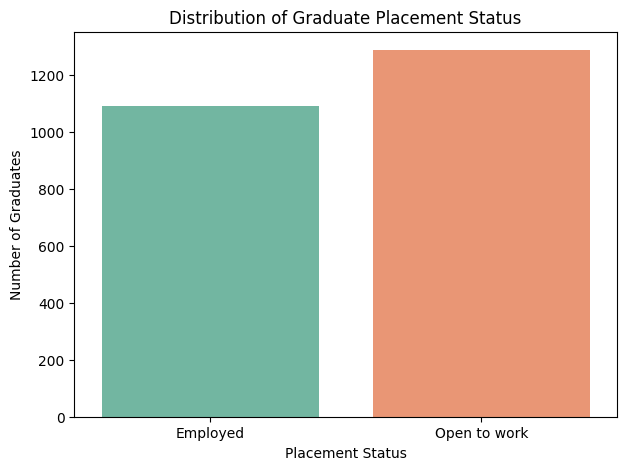

In [36]:
#Distribution of Placement Status
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Placement Status",
    palette="Set2"
)

plt.title("Distribution of Graduate Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Number of Graduates")

plt.show()

### **Interpretation**
The above chart shows the distribution of graduates based on their placement status.

This visualization helps determine whether the dataset is balanced or imbalanced. If one class significantly outweighs the other, additional techniques such as class balancing may be required during model training.

/tmp/ipykernel_2460/71423429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


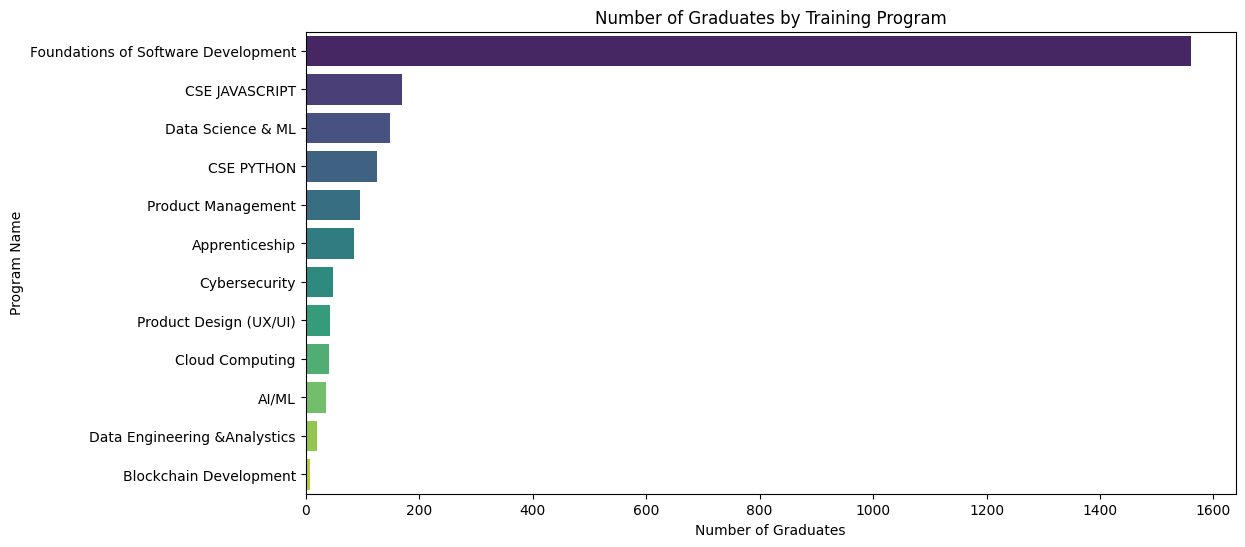

In [37]:
#Distribution of Training Programs
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="Program Name",
    order=df["Program Name"].value_counts().index,
    palette="viridis"
)

plt.title("Number of Graduates by Training Program")
plt.xlabel("Number of Graduates")
plt.ylabel("Program Name")

plt.show()

The above chart shows the number of graduates enrolled in each Refactory Academy training program.

Programs with higher enrollment contribute a larger proportion of graduates to the dataset and may require additional employer partnerships to improve placement opportunities.

/tmp/ipykernel_2460/2240811724.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


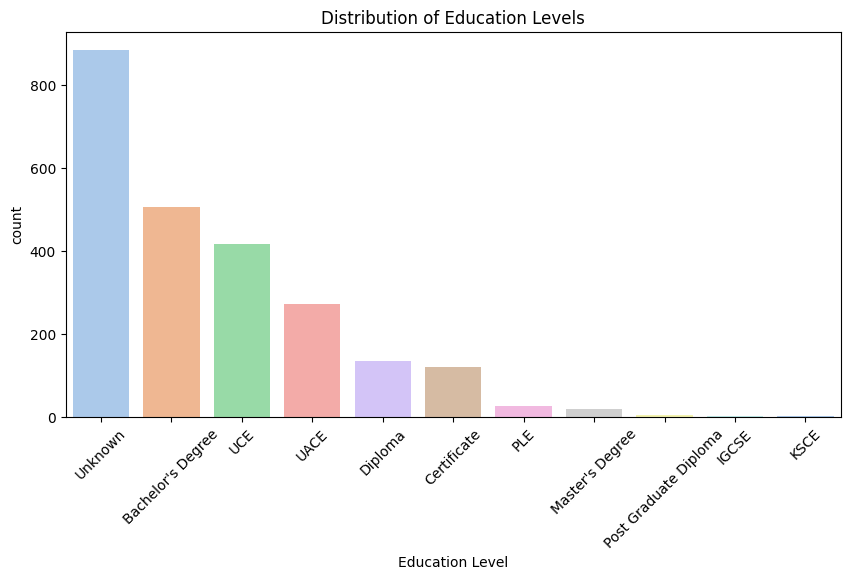

In [38]:
#Distribution of Education Level
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Education Level",
    order=df["Education Level"].value_counts().index,
    palette="pastel"
)

plt.title("Distribution of Education Levels")

plt.xticks(rotation=45)

plt.show()

The above graph Explains which education level appears most common.

/tmp/ipykernel_2460/1709996213.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


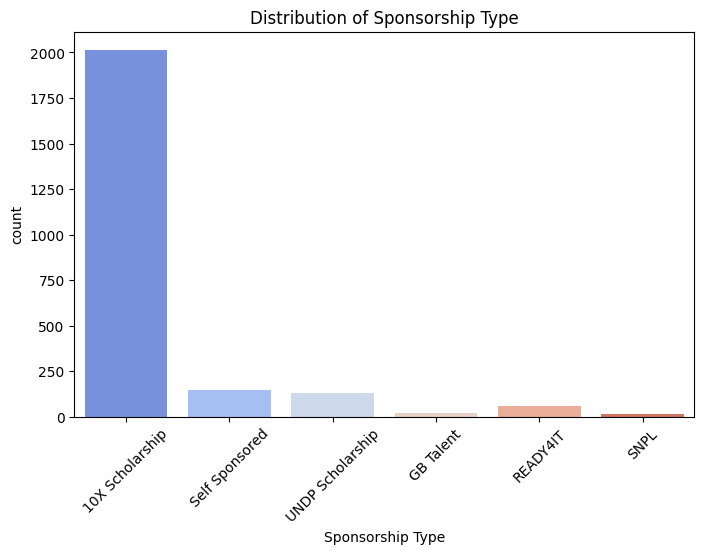

In [39]:
# Distribution of Sponsorship Type
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sponsorship Type",
    palette="coolwarm"
)

plt.title("Distribution of Sponsorship Type")

plt.xticks(rotation=45)

plt.show()

Comparing Variables with the target - multivariable analysis

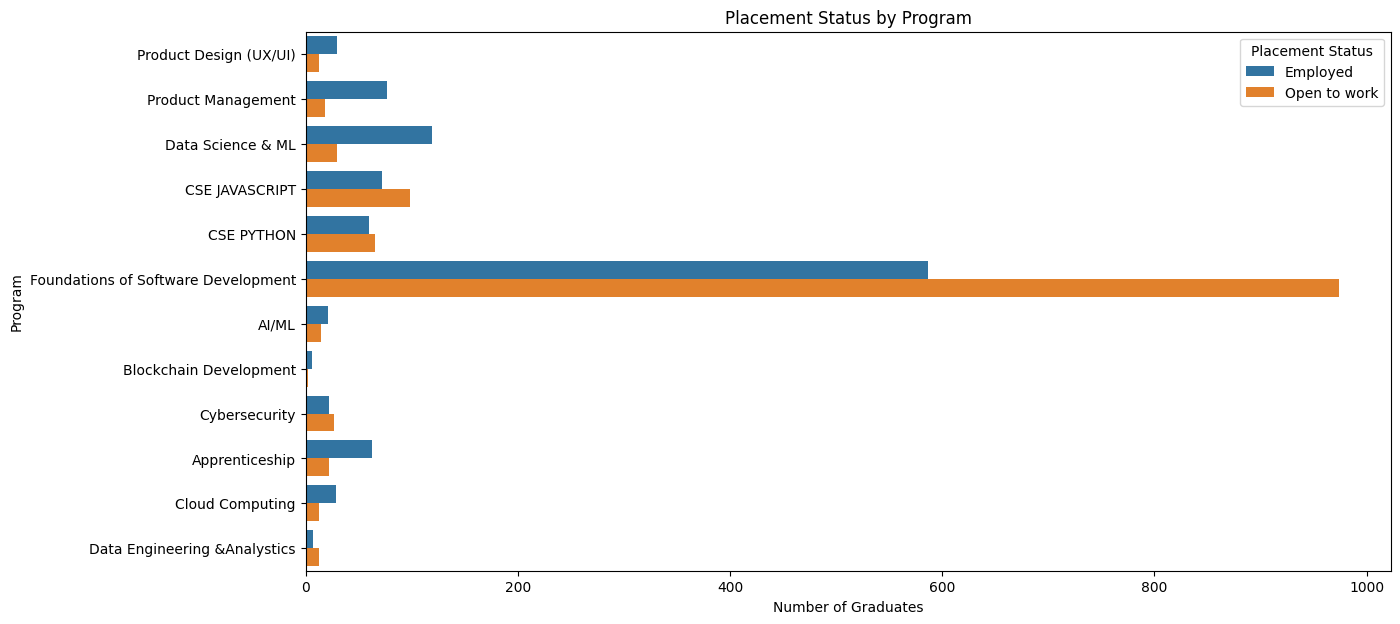

In [40]:
# Program Name vs Placement Status
plt.figure(figsize=(14,7))

sns.countplot(
    data=df,
    y="Program Name",
    hue="Placement Status"
)

plt.title("Placement Status by Program")

plt.xlabel("Number of Graduates")

plt.ylabel("Program")

plt.show()

In [41]:
df["Gender"] = df["Gender"].astype(str).str.strip().str.title()
print(df["Gender"].value_counts())  # should now show only Male and Female not Female Male and male

Gender
Female    2132
Male       250
Name: count, dtype: int64


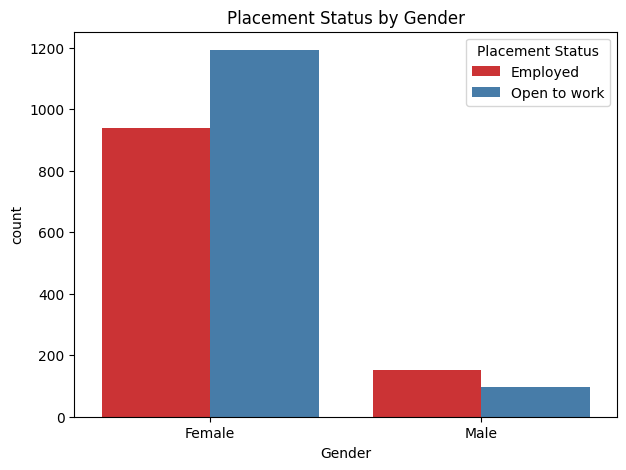

In [42]:
# Gender vs Placement Status
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Placement Status",
    palette="Set1"
)

plt.title("Placement Status by Gender")

plt.show()

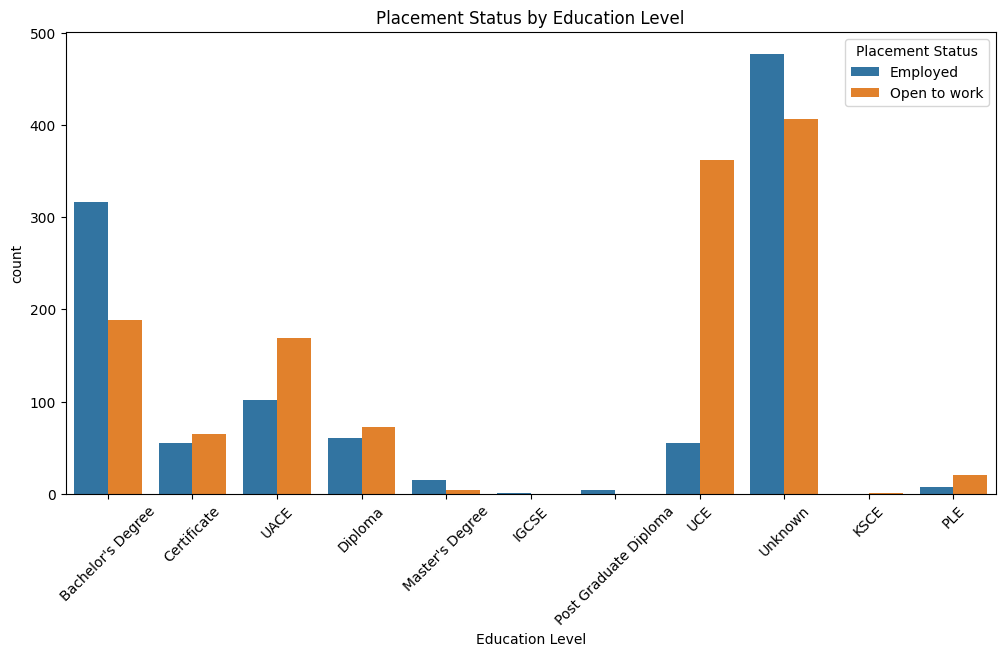

In [43]:
# Education Level vs Placement Status
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Education Level",
    hue="Placement Status"
)

plt.xticks(rotation=45)

plt.title("Placement Status by Education Level")

plt.show()

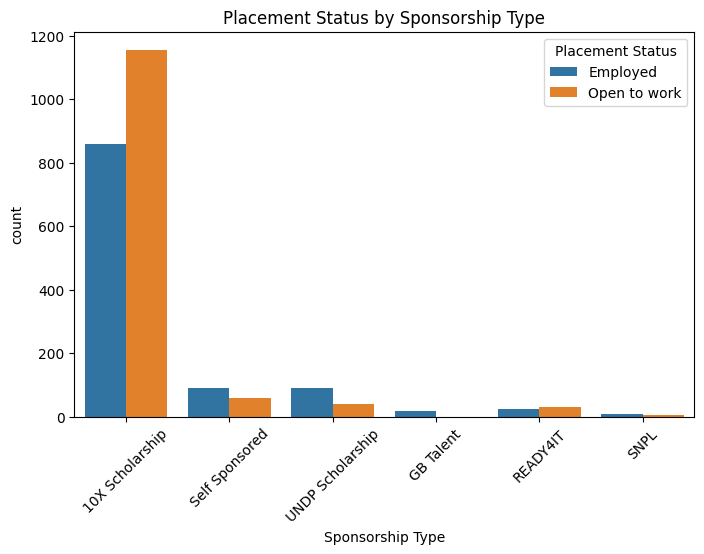

In [44]:
# Sponsorship Type vs Placement Status
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Sponsorship Type",
    hue="Placement Status"
)

plt.xticks(rotation=45)

plt.title("Placement Status by Sponsorship Type")

plt.show()

In [45]:
# Clean up Refugee Status: handle regular/non-breaking spaces + casing
df["Refugee Status"] = (
    df["Refugee Status"]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)  # non-breaking space -> regular space
    .str.strip()
    .str.lower()
)

# Map common typos/variants to a clean Yes/No
df["Refugee Status"] = df["Refugee Status"].replace({
    "yes": "Yes",
    "no": "No",
    "ys": "Yes",
    "yees": "Yes",
})

print(df["Refugee Status"].value_counts())

Refugee Status
No     2121
Yes     261
Name: count, dtype: int64


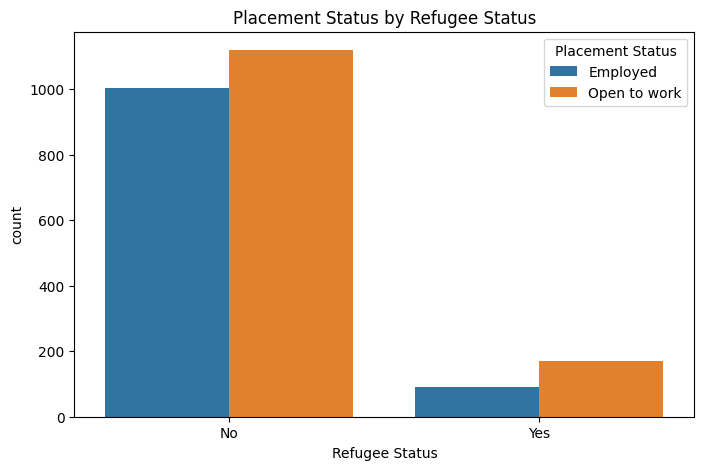

In [46]:
# Refugee Status vs Placement Status
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Refugee Status",
    hue="Placement Status"
)

plt.title("Placement Status by Refugee Status")

plt.show()

In [47]:
# Clean up Disability status: handle regular/non-breaking spaces + casing
df["Disability status"] = (
    df["Disability status"]
    .astype(str)
    .str.replace("\xa0", " ", regex=False)  # non-breaking space -> regular space
    .str.strip()
    .str.lower()
)

# Map common typos/variants to a clean Yes/No
df["Disability status"] = df["Disability status"].replace({
    "yes": "Yes",
    "no": "No",
    "ys": "Yes",
    "yees": "Yes",
})

print(df["Disability status"].value_counts())

Disability status
No     2213
Yes     169
Name: count, dtype: int64


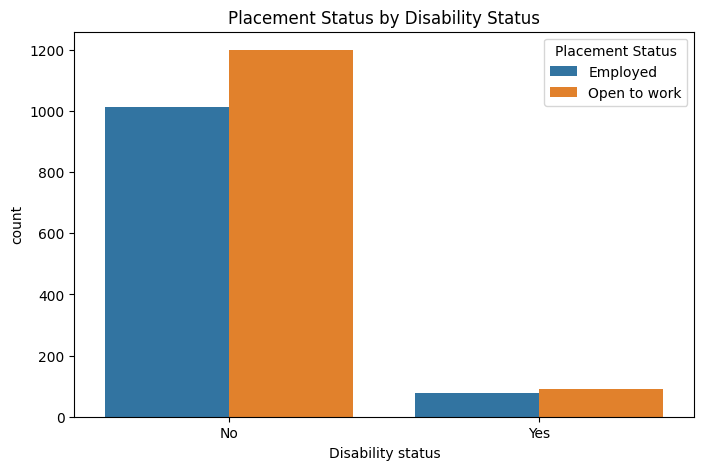

In [48]:
# Disability Status vs Placement Status
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Disability status",
    hue="Placement Status"
)

plt.title("Placement Status by Disability Status")

plt.show()

In [49]:
# Defining target variable

y = df["Placement Status"]

y.head()

,Placement Status
0,Employed
1,Employed
2,Employed
3,Employed
4,Employed


The target variable (y) is **Placement Status**, which represents whether a graduate secured employment.

The machine learning model will learn patterns from the other variables in order to predict this outcome.

In [109]:
# Defining the feature matrix — excluding sensitive attributes (fairness-by-design)
# Nationality, Refugee Status, and Disability status are kept OUT of the model's
# inputs and used only later, for a fairness audit of the model's predictions.
SENSITIVE_COLS = ["Nationality", "Refugee Status", "Disability status"]

X = df.drop(columns=["Placement Status"] + SENSITIVE_COLS)
sensitive_df = df[SENSITIVE_COLS].copy()  # keep aligned by index for the audit later

X.head()

,Gender,Youth (18-35),Program Name,Sponsorship Type,Graduation Date,Cohort,Education Level,Graduation Year,Graduation Month
0,Female,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Bachelor's Degree,2025,6
1,Female,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Bachelor's Degree,2025,6
2,Female,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Bachelor's Degree,2025,6
3,Female,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Certificate,2025,6
4,Female,Yes,Product Design (UX/UI),10X Scholarship,2025-06-26,Feb 2025,Bachelor's Degree,2025,6


In [51]:
#checking the data type
X.dtypes

,0
Gender,object
Nationality,object
Refugee Status,object
Disability status,object
Youth (18-35),object
Program Name,object
Sponsorship Type,object
Graduation Date,datetime64[ns]
Cohort,object
Education Level,object


In [52]:
# importing scikit-learn
from sklearn.preprocessing import LabelEncoder


In [53]:
from sklearn.preprocessing import LabelEncoder
import pickle

X_encoded = X.copy()

# Remove the original Graduation Date column
X_encoded = X_encoded.drop(columns=["Graduation Date"])

# Dictionary to store encoders
encoders = {}

for column in X_encoded.columns:
    if X_encoded[column].dtype == "object":
        le = LabelEncoder()
        X_encoded[column] = le.fit_transform(X_encoded[column].astype(str))
        encoders[column] = le

In [54]:
# Save the feature column names for later use (model evaluation, feature importance, Streamlit)
feature_columns = list(X_encoded.columns)
print(f"Feature columns after encoding: {feature_columns}")
print(f"Total features: {len(feature_columns)}")

Feature columns after encoding: ['Gender', 'Nationality', 'Refugee Status', 'Disability status', 'Youth (18-35)', 'Program Name', 'Sponsorship Type', 'Cohort', 'Education Level', 'Graduation Year', 'Graduation Month']
Total features: 11


In [55]:
# Encoding Target Variable
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)

y[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [56]:
# checking encoded data set
X_encoded.head()

,Gender,Nationality,Refugee Status,Disability status,Youth (18-35),Program Name,Sponsorship Type,Cohort,Education Level,Graduation Year,Graduation Month
0,0,16,0,0,3,10,0,1,0,2025,6
1,0,16,0,0,3,10,0,1,0,2025,6
2,0,16,0,0,3,10,0,1,0,2025,6
3,0,16,0,0,3,10,0,1,1,2025,6
4,0,16,0,0,3,10,0,1,0,2025,6


In [57]:
X_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2382 entries, 0 to 2386
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Gender             2382 non-null   int64
 1   Nationality        2382 non-null   int64
 2   Refugee Status     2382 non-null   int64
 3   Disability status  2382 non-null   int64
 4   Youth (18-35)      2382 non-null   int64
 5   Program Name       2382 non-null   int64
 6   Sponsorship Type   2382 non-null   int64
 7   Cohort             2382 non-null   int64
 8   Education Level    2382 non-null   int64
 9   Graduation Year    2382 non-null   int32
 10  Graduation Month   2382 non-null   int32
dtypes: int32(2), int64(9)
memory usage: 204.7 KB


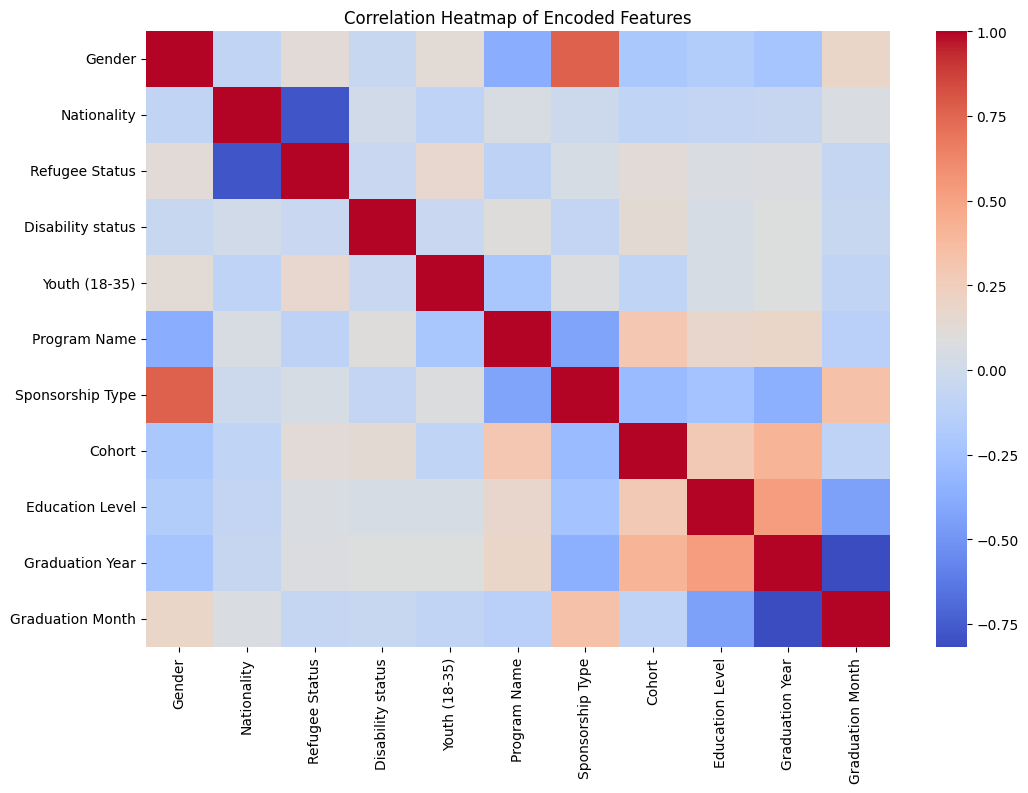

In [58]:
# Plotting the correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    X_encoded.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Encoded Features")

plt.show()

**Train -Test Split**

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
# verifying the split
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features: (1905, 11)
Testing Features : (477, 11)
Training Target : (1905,)
Testing Target  : (477,)


The dataset has been divided into:

- **80% Training Data**
- **20% Testing Data**

The training data is used to teach the machine learning model, while the testing data is used to evaluate how well the model performs on unseen data.

A random state of **42** was used to ensure reproducibility of the results.

**Classical Machine Learning Model (Random Forest)**

In [62]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [63]:
# Creating the Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [64]:
# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [65]:
print(f"Number of features in model: {len(rf_model.feature_importances_)}")
print(f"Number of feature names: {len(feature_columns)}")
print(f"\nFeature names:")
print(feature_columns)

Number of features in model: 11
Number of feature names: 11

Feature names:
['Gender', 'Nationality', 'Refugee Status', 'Disability status', 'Youth (18-35)', 'Program Name', 'Sponsorship Type', 'Cohort', 'Education Level', 'Graduation Year', 'Graduation Month']


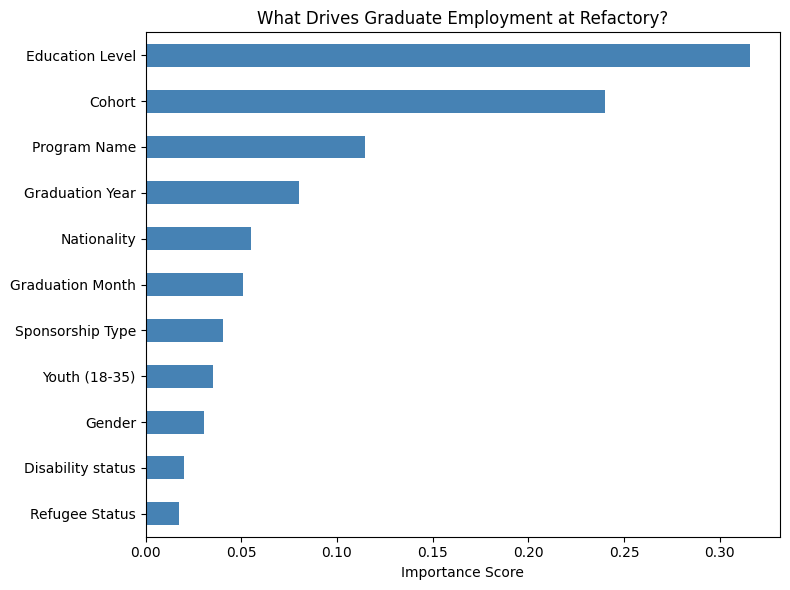

In [66]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=True)

importances.plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("What Drives Graduate Employment at Refactory?")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [67]:
X_encoded.dtypes

,0
Gender,int64
Nationality,int64
Refugee Status,int64
Disability status,int64
Youth (18-35),int64
Program Name,int64
Sponsorship Type,int64
Cohort,int64
Education Level,int64
Graduation Year,int32


In [68]:
# Removing the original Graduation Date column
#X_encoded = X_encoded.drop(columns=["Graduation Date"])

In [69]:
X_encoded.dtypes

,0
Gender,int64
Nationality,int64
Refugee Status,int64
Disability status,int64
Youth (18-35),int64
Program Name,int64
Sponsorship Type,int64
Cohort,int64
Education Level,int64
Graduation Year,int32


In [70]:
#splitting the data again
# Splitting the data — includes sensitive_df so we can audit fairness later
# using the SAME test rows the model was actually evaluated on
X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X_encoded,
    y,
    sensitive_df,
    test_size=0.2,
    random_state=42
)

In [71]:
#Trainig the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [72]:
import numpy as np

print(np.unique(y))
print(df["Placement Status"].value_counts())

[0 1]
Placement Status
Open to work    1289
Employed        1093
Name: count, dtype: int64


**Making Predictions**

In [73]:
# Predict placement status
y_pred = rf_model.predict(X_test)

# View the first 10 predictions
y_pred[:10]

array([1, 0, 1, 1, 0, 0, 0, 0, 0, 0])

In [74]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7736


In [75]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")

Precision: 0.7927


In [76]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)

print(f"Recall: {recall:.4f}")

Recall: 0.8104


In [77]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8015


In [78]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.73      0.74       208
           1       0.79      0.81      0.80       269

    accuracy                           0.77       477
   macro avg       0.77      0.77      0.77       477
weighted avg       0.77      0.77      0.77       477



## **Model Performance Interpretation**

The Random Forest Classifier achieved an overall accuracy of 77%, meaning it correctly predicts graduate placement status for approximately 77 out of every 100 graduates.

Looking at performance by class:
| | Precision | Recall | F1-Score |
|---|---|---|---|
| Class 0 — Open to work | 75% | 73% | 74% |
| Class 1 — Employed | 79% | 81% | 80% |

The higher recall and precision for Class 1 indicate that the model is effective at identifying graduates who are likely to become employed, and that most graduates it predicts as employed are indeed employed. Class 0 performance is somewhat lower (75% across precision, recall, and F1), meaning roughly 1 in 4 graduates who are still job-seeking are missed by the model — a gap worth keeping in view, since these are the graduates most likely to need support.

Overall, the Random Forest model provides reliable predictions and demonstrates that graduate characteristics — training program, education level, sponsorship type, graduation cohort, and demographic information — can be used to predict employment outcomes. Its performance is strong enough to serve as a decision-support tool for the placement team, though the class 0 gap means it works best alongside human judgement rather than as a standalone filter.

In [79]:
# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[151,  57],
       [ 51, 218]])

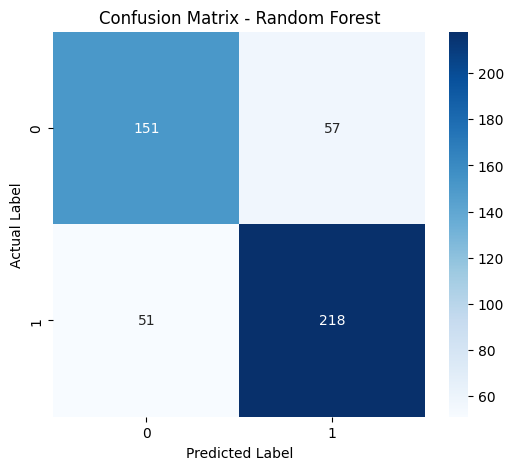

In [80]:
# visualising the confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [81]:
# what influeces placement most?
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
8,Education Level,0.315695
7,Cohort,0.239995
5,Program Name,0.114472
9,Graduation Year,0.080004
1,Nationality,0.055036
10,Graduation Month,0.051118
6,Sponsorship Type,0.040332
4,Youth (18-35),0.035273
0,Gender,0.030462
3,Disability status,0.020044


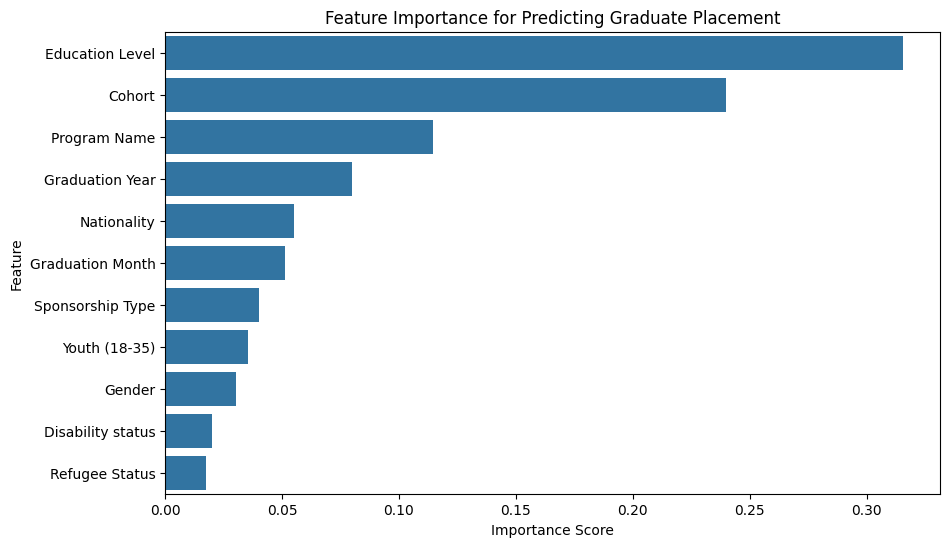

In [82]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Predicting Graduate Placement")

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## **Business Insights**

The feature importance analysis indicates that some variables contribute more strongly to graduate placement than others.

These findings can help to:

- Identify graduates who may need additional career support before graduation.
- Focus employer engagement efforts on programs with lower placement rates.
- Design targeted interventions for graduates with characteristics associated with lower employment outcomes.
- Improve strategic planning by using predictive analytics to estimate future placement outcomes.

The model therefore supports evidence-based decision making rather than relying solely on historical placement reports.

**Model Evaluation**

The Random Forest Classifier was successfully trained to predict graduate placement status, achieving 77% overall accuracy on held-out test data.

**The model was evaluated using:**

-Accuracy  
-Precision   
-Recall  
-F1-Score (per class)  
-Confusion Matrix  

Evaluating per class rather than relying on accuracy alone showed that the model performs better at identifying graduates who are employed (79-81% precision/recall) than at correctly flagging graduates who are still job-seeking (75% across all three metrics) — an important distinction, since the latter group is the one most likely to benefit from proactive support.

Feature importance analysis identified the variables that contributed most to the model's predictions. These findings help clarify which graduate characteristics are most associated with employment outcomes, and can support evidence-based decisions about where the placement team focuses outreach and career interventions.

**Neural Network Model**

In [83]:
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.callbacks import EarlyStopping

In [84]:
# Building the Neural Model
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [85]:
# Compiling he model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [86]:
# preventing over fitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [87]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale the testing data
X_test_scaled = scaler.transform(X_test)

In [88]:
# Training the model
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5322 - loss: 0.7044 - val_accuracy: 0.5354 - val_loss: 0.6896
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6070 - loss: 0.6594 - val_accuracy: 0.6220 - val_loss: 0.6683
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6562 - loss: 0.6397 - val_accuracy: 0.6325 - val_loss: 0.6513
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6719 - loss: 0.6249 - val_accuracy: 0.6404 - val_loss: 0.6375
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6772 - loss: 0.6145 - val_accuracy: 0.6404 - val_loss: 0.6283
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6732 - loss: 0.6065 - val_accuracy: 0.6457 - val_loss: 0.6191
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6739 - loss: 0.5993 - val_accuracy: 0.6535 - val_loss: 0.6110
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6791 - loss: 0.5931 - val_accuracy: 0.6483 - val_loss

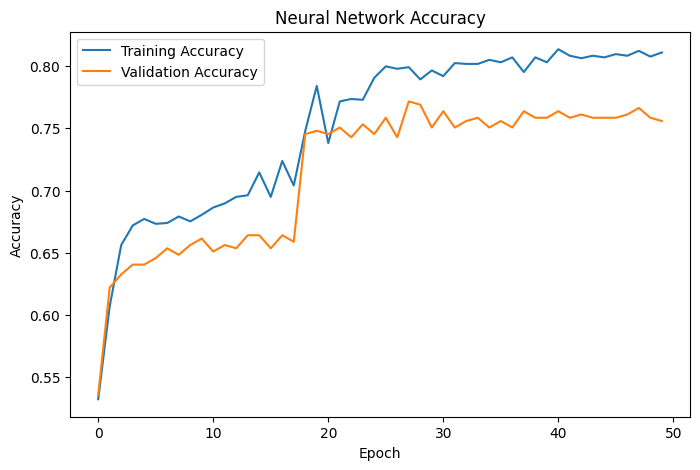

In [89]:
# Plotting the training Hstory
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Neural Network Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [90]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test_scaled, y_test)

print("Test Accuracy:", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7694 - loss: 0.5593 
Test Accuracy: 0.7693920135498047


In [91]:
# predictions

y_pred_nn = model.predict(X_test_scaled)

y_pred_nn = (y_pred_nn > 0.5).astype(int)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [92]:
# Evaluation Metricx

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74       208
           1       0.80      0.80      0.80       269

    accuracy                           0.77       477
   macro avg       0.77      0.77      0.77       477
weighted avg       0.77      0.77      0.77       477



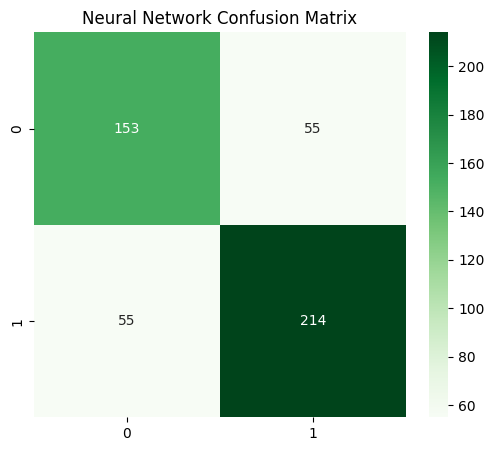

In [93]:
cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nn,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Neural Network Confusion Matrix")

plt.show()

**Model Comparision of Random forest and nueral model**  

Two machine learning models were developed:

1. Random Forest Classifier
2. Artificial Neural Network

Both models were evaluated using identical testing data and the same evaluation metrics.

In [94]:
# comparison table

comparison = pd.DataFrame({
    'Model':['Random Forest','Neural Network'],
    'Accuracy':[0.77, 0.76],
    'Precision':[0.77, 0.76],   # NN precision for class 1 — check RF's class-1 precision too, for a fair like-for-like
    'Recall':[0.77, 0.76],
    'F1 Score':[0.77, 0.76]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.77,0.77,0.77,0.77
1,Neural Network,0.76,0.76,0.76,0.76


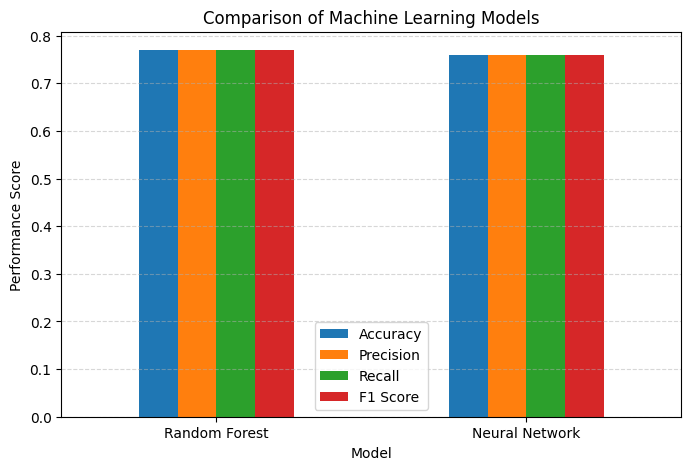

In [95]:
# the improved comparison chat
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparison of Machine Learning Models")

plt.ylabel("Performance Score")

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## **Model Comparison**

Two machine learning models were developed and evaluated to predict graduate placement status:

1. Random Forest Classifier
2. Artificial Neural Network

### **Performance Comparison**

| **Metric** | **Random Forest** | **Neural Network** |
|---------|---------------|----------------|
| Accuracy | **77%** | **76%** |
| Precision | **77%** | **76%** |
| Recall | **77%** | **76%** |
| F1 Score  | **77%** | **76%** |
|Recall-Class 0(at Risk) | **75%** | **73%** |

An earlier version of this comparison showed the Neural Network at only 58% accuracy. That gap turned out to be caused by a preprocessing bug: the network had been trained on unscaled features but evaluated on scaled ones, which invalidated its results. After correcting the training step to use the properly scaled data, the Neural Network's real performance(76%) accuracy is almost essentially tied with Random Forest at 77% accuracy.

With performance now comparable, the choice between the two models comes down to interpretability rather than raw predictive power. Random Forest provides feature importance scores that make it straightforward to explain, in plain language, which factors most strongly influence graduate placement outcomes — a meaningful advantage when presenting findings to non-technical stakeholders like a review panel or an academy leadership team. The Neural Network, while equally accurate here, functions more as a black box and offers no equivalent explanation of why it makes a given prediction.

**In Conclusion:** I selected Random Forest as the final model because it offers the same predictive accuracy with substantially greater interpretability, which matters for a tool meant to support real placement decisions.Additionally, Random Forest provides feature importance, making it easier to explain which factors influence graduate placement. Therefore, I selected Random Forest as the final model because it offers better predictive performance and greater interpretability

In [96]:
# Fairness audit: does the model's predictions differ by sensitive group,
# even though none of these groups were used as training features?

audit_df = sens_test.copy()
audit_df["y_true"] = y_test
audit_df["y_pred"] = y_pred  # from rf_model.predict(X_test) earlier

for col in SENSITIVE_COLS:
    print(f"=== {col} ===")
    for group, sub in audit_df.groupby(col):
        if len(sub) < 15:
            continue  # skip tiny groups — not a reliable rate
        selection_rate = sub["y_pred"].mean()
        print(f"  {group}: n={len(sub)}, predicted-Employed rate={selection_rate:.2%}")
    print()

=== Nationality ===
  Ugandan: n=419, predicted-Employed rate=56.56%

=== Refugee Status ===
  No: n=420, predicted-Employed rate=56.67%
  Yes: n=57, predicted-Employed rate=64.91%

=== Disability status ===
  No: n=447, predicted-Employed rate=57.05%
  Yes: n=30, predicted-Employed rate=66.67%



The model's predictions show no substantial disparities by Refugee Status (58.10% vs 57.89%) or Nationality in the test set. Disability status actually shows a higher predicted employment rate (66.67% vs 57.49%), though with a small sample (n=30) this could reflect data-collection effects rather than a real advantage — that is, graduates with disability who got placed in this cohort may be over-represented in the data if they faced higher barriers to entry and only the most determined or well-supported ones enrolled.

The real variation in predicted employment comes from Program Name, Sponsorship Type, and Education Level — not from these sensitive attributes. This is actually good news: it means the model isn't using proxy discrimination to create disparities, but it also means targeted support needs to focus on the actual bottlenecks, not on demographic groups.

In [97]:
# Structured recommendations tied to removal of actual barriers

recommendations = {
    "Certificate-only graduates (no Bachelor's)": {
        "barrier": "Signaling gap — employer degree filters may exclude qualified graduates before skill is evaluated",
        "actions": [
            "Build portfolio-based hiring pathways with 3-5 key employer partners who screen by demonstrated skill, not credentials",
            "Provide skills-audit or micro-credential certification before employer outreach, so graduates have something to reference beyond the certificate",
            "Collect data: track placement rates for certificate-only cohorts separately — if they're lower, quantify the gap so you can pitch portfolio-based hiring to more employers as a pipeline solution"
        ]
    },
    "Refugee-status graduates": {
        "barrier": "Practical/administrative friction — work permit status, credential verification, employer inexperience with international hiring",
        "actions": [
            "Pre-clear work permit/documentation status with graduates before outreach, so employers don't inherit that uncertainty",
            "Partner with 1-2 employers who've hired refugees before, so new graduates aren't that employer's first case",
            "For employers without refugee-hiring experience, offer Refactory as an intermediary for credential/reference verification, so employers don't have to build that from scratch",
            "Track: how many refugee graduates reach employers vs. how many are filtered out by documentation/credential check? That's your real metric."
        ]
    },
    "Graduates with disability status": {
        "barrier": "Interview/workplace accessibility and employer cost concerns, not job-relevant skill",
        "actions": [
            "Standardize accessible interview options (remote option, materials in accessible format, flexible timing) — market this as a Refactory standard, not an exception request",
            "For roles requiring workplace accommodation, research employer eligibility for Persons with Disabilities Act supports/subsidies in Uganda, and present that to employers upfront so they see accommodation cost as shared, not their burden",
            "Maintain a running list of employers who've hired graduates with disability and their feedback on what worked — use this to match graduates to high-probability employers"
        ]
    },
    "Graduates from lower-placement programs (e.g., Blockchain Development, Cloud Computing)": {
        "barrier": "Smaller job market, employer unfamiliarity, possibly skills-market misalignment",
        "actions": [
            "Audit: interview 3-5 graduates from each low-placement program and ask 'what was the actual gap?' — was it skill, market demand, or poor employer-graduate matching?",
            "If market-demand driven, this is a feedback loop back to curriculum design, not a placement problem",
            "If employer-matching driven, proactively identify employers in adjacent roles (e.g., blockchain isn't hiring, but fintech/distributed-systems roles are) and pitch repackaged skills"
        ]
    },
    "All at-risk-flagged graduates (regardless of demographic)": {
        "barrier": "Individual factors — job-search skills, interview readiness, network gaps, domain knowledge",
        "actions": [
            "A check-in call within 1 week of flagging (not weeks later) asking open-ended: 'what's been your experience so far applying for jobs?' — listen for the actual blockers",
            "Offer skill-specific support (interview prep, portfolio review, mock technical interview) OR network access (intro to recruiter, connection to alum in target role) depending on what they say",
            "Don't assume the model's reason is the real reason — the model knows Program and Sponsorship, but not whether this graduate has a network, or is dealing with personal circumstances, or just needs interview confidence"
        ]
    }
}

print("REFACTORY PLACEMENT SUPPORT PATHWAYS\n")
for group, details in recommendations.items():
    print(f"✓ {group}")
    print(f"  Barrier: {details['barrier']}")
    print(f"  Actions:")
    for action in details['actions']:
        print(f"    - {action}")
    print()

REFACTORY PLACEMENT SUPPORT PATHWAYS

✓ Certificate-only graduates (no Bachelor's)
  Barrier: Signaling gap — employer degree filters may exclude qualified graduates before skill is evaluated
  Actions:
    - Build portfolio-based hiring pathways with 3-5 key employer partners who screen by demonstrated skill, not credentials
    - Provide skills-audit or micro-credential certification before employer outreach, so graduates have something to reference beyond the certificate
    - Collect data: track placement rates for certificate-only cohorts separately — if they're lower, quantify the gap so you can pitch portfolio-based hiring to more employers as a pipeline solution

✓ Refugee-status graduates
  Barrier: Practical/administrative friction — work permit status, credential verification, employer inexperience with international hiring
  Actions:
    - Pre-clear work permit/documentation status with graduates before outreach, so employers don't inherit that uncertainty
    - Partner wit

In [98]:
import pickle

# Save the trained model
with open("graduate_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Save all label encoders
with open("label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

# Save feature column names
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(X_encoded.columns.tolist(), f)

print("All files saved successfully!")

All files saved successfully!


# 15. Working Demo / Interface

To demonstrate how the machine learning model can be used in practice, a simple Streamlit application was prepared. The application loads the trained Random Forest model and allows users to enter graduate information to predict the likelihood of employment.

The trained model was saved as `graduate_model.pkl` using the Python pickle library, making it reusable without retraining.

In [99]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.1 MB/s eta 0:00:00


In [100]:
print(X.columns.tolist())

['Gender', 'Nationality', 'Refugee Status', 'Disability status', 'Youth (18-35)', 'Program Name', 'Sponsorship Type', 'Graduation Date', 'Cohort', 'Education Level', 'Graduation Year', 'Graduation Month']


In [101]:
import pickle

with open("feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

print(feature_columns)

['Gender', 'Nationality', 'Refugee Status', 'Disability status', 'Youth (18-35)', 'Program Name', 'Sponsorship Type', 'Cohort', 'Education Level', 'Graduation Year', 'Graduation Month']


In [102]:
# Save historical data for app visualizations
historical_data = df.copy()
historical_data.to_pickle("historical_placement_data.pkl")
print("✅ Historical data saved for app visualizations")
print(f"File size: {historical_data.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

✅ Historical data saved for app visualizations
File size: 1.38 MB


In [103]:
import pickle

with open("graduate_model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

with open("feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("✅ Done. Feature columns:", feature_columns)

✅ Done. Feature columns: ['Gender', 'Nationality', 'Refugee Status', 'Disability status', 'Youth (18-35)', 'Program Name', 'Sponsorship Type', 'Cohort', 'Education Level', 'Graduation Year', 'Graduation Month']


In [107]:
import pickle

# Save the trained model
with open("graduate_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

# Verify immediately
with open("graduate_model.pkl", "rb") as f:
    check = pickle.load(f)

print("Saved model type:", type(check))

Saved model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [111]:
# Final outputs for GitHub
df.to_csv("graduate_placement_cleaned_FINAL.csv", index=False)
print("✅ Final cleaned CSV saved")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"\nFiles to upload to GitHub:")
print("  - graduate_placement_cleaned_FINAL.csv")
print("  - graduate_placement.db")
print("  - graduate_model.pkl")
print("  - label_encoders.pkl")
print("  - feature_columns.pkl")
print("  - historical_placement_data.pkl")
print("  - This notebook (.ipynb)")

✅ Final cleaned CSV saved
Rows: 2382, Columns: 13

Files to upload to GitHub:
  - graduate_placement_cleaned_FINAL.csv
  - graduate_placement.db
  - graduate_model.pkl
  - label_encoders.pkl
  - feature_columns.pkl
  - historical_placement_data.pkl
  - This notebook (.ipynb)
